In [4]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
import array as r
from klepto.archives import file_archive
from mpl_toolkits.aes_grid1 import make_aes_locatable
import numpy as np
import numpy.ma as ma
from scipy.optimize import least_squares

In [ ]:
# utility for path averaging that was used to process the raw data. Not required to recreate the figure, but added for completeness. 

def find_nearest(array_x, value_x):
    idx = np.sqrt((array_x - value_x)**2).argmin()
    return idx

def calc_cont(ssh, lon_start, lat_start, y_fin, N_smooth_cont, N_smooth_der, I):

    # function that calculates contour, arclength and values of alpha (equation 9 of supplementary material)
    
    ssh = ssh.T # coordinate axes convenience
    contours = measure.find_contours(ssh.values, 0)
    # print(I, len(contours))
    
    len_cont = [np.shape(contours[i])[0] for i in range(len(contours))]
    ind = (len_cont - np.max(len_cont)).argmax()
    #contour_coors = contours[ind][::-1,:]
    
    lat_gulf = 30
    lon_gulf = -80
    d_min = np.zeros(len(contours))
    
    lat_mod = ssh.y.values
    lon_mod = ssh.x.values
    
    for i in range(len(contours)):
        d = np.zeros(len(contours[i][:,0]))
        for j in range(len(contours[i][:,0])):
            len_cont = [np.shape(contours[i])[0] for i in range(len(contours))]
    
            lat_t = contours[i][j,0]/np.shape(ssh)[0]*(lat_mod[-1] - lat_mod[0]) + lat_mod[0]
            lon_t = contours[i][j,1]/np.shape(ssh)[1]*(lon_mod[-1] - lon_mod[0]) + lon_mod[0]
            d[j] = (lat_t - lat_gulf)**2 + (lon_t - lon_gulf)**2
        d_min[i] = d.min()
    
    ind = d_min.argmin()
    contour_coors = contours[ind][::-1,:]
    
    lat = contour_coors[:,0]/np.shape(ssh)[0]*(lat_mod[-1] - lat_mod[0]) + lat_mod[0]
    lon = contour_coors[:,1]/np.shape(ssh)[1]*(lon_mod[-1] - lon_mod[0]) + lon_mod[0]
    
    # smoothen contour
    dx_shift = (lon[2:] - lon[:-2])/2/180*np.pi*np.cos(lat[1:-1]/180*np.pi)*R
    dy_shift = (lat[2:] - lat[:-2])/2/180*np.pi*R
    dy = np.sqrt(dx_shift**2 + dy_shift**2)
    
    lat = np.convolve(lat[1:-1]*dy, np.ones(N_smooth_cont), mode = 'valid') / np.convolve(dy, np.ones(N_smooth_cont), mode = 'valid')
    lon = np.convolve(lon[1:-1]*dy, np.ones(N_smooth_cont), mode = 'valid') / np.convolve(dy, np.ones(N_smooth_cont), mode = 'valid')

    # calculate arclength and orthogonal vectors 
    N = len(lat)
    t_vec = np.zeros([N-1, 2]) # vector to hold orthogonal directions
    dx_shift = (lon[1:] - lon[:-1])/180*np.pi*np.cos(lat[:-1]/180*np.pi)*R
    dy_shift = (lat[1:] - lat[:-1])/180*np.pi*R
    dy = np.sqrt(dx_shift**2 + dy_shift**2)
    t_vec[:,0] = dy_shift/dy # t_vec holdy the vector orthogonal to the path in local cartesian coordinates
    t_vec[:,1] = -dx_shift/dy 
    y = np.cumsum(dy)
    
    # smoothen orthogonal vector
    t_vec_smooth = np.zeros([N-N_smooth_der,2])
    t_vec_smooth[:,0] = np.convolve(t_vec[:,0]*dy, np.ones(N_smooth_der), mode = 'valid') / np.convolve(dy, np.ones(N_smooth_der), mode = 'valid')
    t_vec_smooth[:,1] = np.convolve(t_vec[:,1]*dy, np.ones(N_smooth_der), mode = 'valid') / np.convolve(dy, np.ones(N_smooth_der), mode = 'valid')
    t_vec = t_vec_smooth

    # cut other vectors accordingly
    y = y[int(N_smooth_der/2):-int(N_smooth_der/2)]
    dy = dy[int(N_smooth_der/2):-int(N_smooth_der/2)]
    lon = lon[int(N_smooth_der/2):-int(N_smooth_der/2)]
    lat = lat[int(N_smooth_der/2):-int(N_smooth_der/2)]

    # calculate radius of curvature along central axis to avoid taking averages where local coordinates system is not well posed
    dx_shift = (lon[1:] - lon[:-1])/180*np.pi*np.cos(lat[:-1]/180*np.pi)*R # calculate distance in local cartesian differentials
    dy_shift = (lat[1:] - lat[:-1])/180*np.pi*R
    curvature = ((dy_shift*t_vec[1:,0] - dx_shift*t_vec[1:,1])/(t_vec[:-1,1]*t_vec[1:,0] - t_vec[:-1,0]*t_vec[1:,1]))

    # cut other vectors accordingly
    t_vec = t_vec[:-1,:]
    y = y[:-1]
    lon = lon[:-1]
    lat = lat[:-1]

    # smoothen inverse curvature
    curv_smooth = np.zeros([N-N_smooth_der])
    curv_inv_smooth = np.convolve(1/curvature*dy, np.ones(N_smooth_der), mode = 'valid') / np.convolve(dy, np.ones(N_smooth_der), mode = 'valid')
    curvature = 1/curv_inv_smooth

    # cut other vectors accordingly
    y = y[int(N_smooth_der/2):-int(N_smooth_der/2)]
    lon = lon[int(N_smooth_der/2):-int(N_smooth_der/2)]
    lat = lat[int(N_smooth_der/2):-int(N_smooth_der/2)]
    t_vec = t_vec[int(N_smooth_der/2):-int(N_smooth_der/2)]
    
    # find starting index
    idx_start = find_nearest(lon, lon_start)
    d = np.zeros(len(lon))
    for j in range(len(lon)):
        lat_t = lat[j]
        lon_t = lon[j]
        d[j] = (lat_t - lat_start)**2 + (lon_t - lon_start)**2

    idx_start = d.argmin()
    
    # find ending index
    #idx_end = find_nearest(lon[:2000], lon_end)
    
    # cut vectors
    lat_cont = lat[idx_start:]#idx_end]
    lon_cont = lon[idx_start:]#idx_end]
    t_vec = t_vec[idx_start:]#idx_end]
    y = y[idx_start:] - y[idx_start]
    curvature = curvature[idx_start:]
        
    # cut array to specific arclength
    ii = find_nearest(y, y_fin)
    
    lon_cont = lon_cont[:ii]
    lat_cont = lat_cont[:ii]
    t_vec = t_vec[:ii]
    y = y[:ii]
    curvature = curvature[:ii]
    
    return lon_cont, lat_cont, t_vec, y, curvature

def transform(x, t_vec, lat_cont, lon_cont):

    ''' Function that performs a coordinate transform from along/across stream coordinates (y, x) to longitude and latitude. '''
    
    #longitudes
    lons = lon_cont + t_vec[:,0]*x/(2*np.pi*R*np.cos(lat_cont/180*np.pi))*360
    #latitudes 
    lats = lat_cont + t_vec[:,1]*x/(2*R*np.pi)*360

    return lons, lats
    
def calc_path_average(I):

    # function that calculates the y-integrals in the denominator and numerator of equations 11 and 12 for one snapshot.
    
    # open data
    
    # topo mask 
    ds_topo = xr.open_dataset(path + "topo.nc")
    topo = ds_topo["zb"][0,:,:,:].transpose("x", "y","level")
    topo = topo[:,:,0]
    
    # isopycs
    isopycs_ds = xr.open_dataset(path + "2048.nc", decode_times=False)
    isopycs = isopycs_ds["h"].transpose("time", "x", "y", "level")
    isopycs = isopycs[I + 1,:,:,:]
    isopycs = np.cumsum(isopycs, axis = -1) + topo       
    isopycs_v = isopycs.values
    isopycs_v[topo > 0] = np.nan
    isopycs.values = isopycs_v
    lat = isopycs.y
    lon = isopycs.x
    
    # us
    us_ds = xr.open_dataset(path + "2048.nc", decode_times=False)
    us = us_ds["u.x"].transpose("time", "x", "y", "level")
    us = us[I + 1,:,:,:]
    usv = us.values
    usv[topo > 0] = np.nan
    us.values = usv
    
    # vs
    vs_ds = xr.open_dataset(path + "2048.nc", decode_times=False)
    vs = vs_ds["u.y"].transpose("time", "x", "y", "level")
    vs = vs[I + 1,:,:,:]
    vsv = vs.values
    vsv[topo > 0] = np.nan
    vs.values = vsv

    # calculate contour
    lon_cont, lat_cont, t_vec, y, curvature = calc_cont(isopycs[:,:,-1], lon_start, lat_start, y_fin, N_smooth_cont, N_smooth_der, I)

    N = len(lon_cont)

    # create mask that activates beyond radius of curvature
    nan_mask = np.zeros([N-1,N_across])
    
    for j in range(N-1):
        if curvature[j] > 0:
            for i, x in enumerate(xs):
                if x > curvature[j]:
                    nan_mask[j,i] = 1
        if curvature[j] <= 0:
            for i, x in enumerate(xs):
                if x <= curvature[j]:
                    nan_mask[j,i] = 1
    
    # longitudes and latitudes of stream-wise coordinates
    path_lons, path_lats = transform(xs[None,:], t_vec[:,:,None], lat_cont[:,None], lon_cont[:,None]) 
    
    # calculate along-stream distances in local cartesian differentials x (along longitudinal direction) and y (along latitudinal direction)
    dx_shift = (path_lons[2:] - path_lons[:-2])/2/180*np.pi*np.cos(path_lats[1:-1,:]/180*np.pi)*R 
    dy_shift = (path_lats[2:] - path_lats[:-2])/2/180*np.pi*R
    dy = np.sqrt(dx_shift**2 + dy_shift**2) # array that holds infinitessimal distances as a function of x
    
    # apply mask
    for j in range(0,N-2):
        for i in range(N_across):
            if nan_mask[j,i]:
                dy[j,i] = np.nan
    
    # array that holds arclength as a function of x
    y = np.cumsum(dy, axis = 0)
    
    # shorten arrays to match dy
    path_lons = path_lons[1:-1,:] 
    path_lats = path_lats[1:-1,:]
    t_vec = t_vec[1:-1,:]
    lat_cont = lat_cont[1:-1]
    lon_cont = lon_cont[1:-1]
    curvature = curvature[1:-1]
    
    # create interpolation of isopycs dataset.
    
    yy = isopycs.y.values
    xx = isopycs.x.values
    zz = isopycs.level.values
    data_trans = isopycs.values
    
    isopycs_interp = interpolate.RegularGridInterpolator((xx, yy, zz), data_trans, method = "linear")
    
    # create interpolation of topo dataset.
    
    data_trans = topo.values
    topo_interp = interpolate.RegularGridInterpolator((xx, yy), data_trans, method = "linear")
    
    # create interpolation of u and v dataset.
    
    data_trans = us.values
    u_interp = interpolate.RegularGridInterpolator((xx, yy, zz), data_trans, method = "linear")
    
    data_trans = vs.values
    v_interp = interpolate.RegularGridInterpolator((xx, yy, zz), data_trans, method = "linear")

    # Background rotation parameters
    
    alphas = np.arctan2(t_vec[:,1], t_vec[:,0]) # alpha is the azimuthal angle of the gulf stream direction with the north-south axis and t_vec holds the vector orthogonal to the gulf stream path.
    
    Omega = 2*np.pi/(24*3600) # rotational frequency of the earth
    
    f = 2*Omega*np.sin(path_lats/180*np.pi)
    dfdx = np.zeros(np.shape(f))
         
    for j in range(N-2):
        for i in range(1,N_across-1):
                # centered gradient scheme in the interior
                dfdx[j,i] = (f[j,i+1] - f[j,i-1])/(2*dx)
        # off-center scheme at edges
        dfdx[j,0] = (-3*f[j,0] + 4*f[j,1] - f[j,2])/(2*dx)
        dfdx[j,-1] = (3*f[j,-1] - 4*f[j,-2] + f[j,-3])/(2*dx)
    
    dfdy_denominator = f[-1,:] - f[0,:]

    # interpolate variables in local across-stream coordinates
    
    U_y = np.zeros([N-2, N_across, Nl])
    Isopycs_interp = np.zeros([N-2, N_across, Nl])
    
    for k in range(Nl):
        for i in range(N_across):
                            
            interp_coors = np.zeros([N-2, 3])
            interp_coors[:,0] = path_lons[:,i]
            interp_coors[:,1] = path_lats[:,i]
            interp_coors[:,2] = Nl - 1 - k # change from bottom-to-top indexing (Basilisk) to top-to-bottom (Vallis notation)
            
            Isopycs_interp[:,i,k] = isopycs_interp(interp_coors)
            U_lon = u_interp(interp_coors)
            U_lat = v_interp(interp_coors)
            U_y[:,i,k] = -np.sin(alphas)*U_lon + np.cos(alphas)*U_lat # U_y is the along-stream component of the velocity
    
    # interpolate topography
    Topo_interp = np.zeros([N-2, N_across])
    
    for i in range(N_across):
                
        interp_coors = np.zeros([N-2, 2])
        interp_coors[:,0] = path_lons[:,i]
        interp_coors[:,1] = path_lats[:,i]
        
        Topo_interp[:,i] = topo_interp(interp_coors)
    
    # calculate gradients in x-direction
    dtopo_dx = np.zeros([N-2, N_across])
    
    for j in range(N-2):
        for i in range(1,N_across-1):
                # centered gradient scheme in the interior
                dtopo_dx[j,i] = (Topo_interp[j,i+1] - Topo_interp[j,i-1])/(2*dx)
        # off-center scheme at edges
        dtopo_dx[j,0] = (-3*Topo_interp[j,0] + 4*Topo_interp[j,1] - Topo_interp[j,2])/(2*dx)
        dtopo_dx[j,-1] = (3*Topo_interp[j,-1] - 4*Topo_interp[j,-2] + Topo_interp[j,-3])/(2*dx)
    
    # calculate averaged gradients in y-direction
    delta_topo_dy = (Topo_interp[0,:] - Topo_interp[-1,:])
    
    # add to array
    
    i_core = int((N_across-1)/2)

    numerator_U = np.nansum(U_y*dy[:,:,None], axis = 0)
    numerator_isopycs = np.nansum(Isopycs_interp*dy[:,:,None], axis = 0)
    numerator_topo = np.nansum(Topo_interp*dy,axis = 0)
    numerator_dtopo_dx = np.nansum(dtopo_dx*dy,axis = 0)
    numerator_dtopo_dy = delta_topo_dy
    numerator_f0 = np.nansum(f*dy, axis = 0)
    numerator_dfdx = np.nansum(dfdx*dy, axis = 0)
    numerator_dfdy = dfdy_denominator
    numerator_alpha = np.nansum(alphas*dy[:,i_core], axis = 0)
    denominator_y = np.nansum(dy, axis = 0)

    return numerator_U , numerator_isopycs,  numerator_topo, numerator_dtopo_dx, numerator_dtopo_dy, numerator_f0, numerator_dfdx, numerator_dfdy, numerator_alpha, denominator_y

In [6]:
# utility for fitting the profiles

def fit_2d_function(
    ,
    y,
    z,
    model,
    p0,
    bounds=(-np.inf, np.inf),
    weights=None,
    mask=None,
    **kwargs
):
    """
    Fit an arbitrary analytical function to a 2D dataset.

    Parameters
    ----------
    , y : array_like
        Coordinates of the data points. Can be 1D arrays defining a
        regular grid, or 2D arrays with the same shape as z.

    z : array_like
        2D data to be fitted.

    model : callable
        Analytical model function.

        It must have the form

            model(, y, *params)

        and return an array with the same shape as /y.

    p0 : array_like
        Initial guesses for the model parameters.

    bounds : 2-tuple of array_like, optional
        Lower and upper bounds for the parameters.

    weights : array_like, optional
        Statistical weights for each data point. If supplied, the
        residual is multiplied by these weights.

        For eample, if sigma is the standard deviation of each
        measurement, use weights = 1/sigma.

    mask : array_like of bool, optional
        Boolean mask specifying which data points to include in the fit.
        True = include point.

    **kwargs
        Additional arguments passed to scipy.optimize.least_squares,
        e.g. ma_nfev, ftol, tol, gtol.

    Returns
    -------
    result : scipy.optimize.OptimizeResult
        Full scipy optimization result.

    params : ndarray
        Best-fit parametereturn_scale.

    covariance : ndarray
        Approimate covariance matri of the fitted parametereturn_scale.

    """

     = np.asarray()
    y = np.asarray(y)
    z = np.asarray(z)

    # ------------------------------------------------------------
    # Convert 1D grid coordinates to 2D arrays
    # ------------------------------------------------------------
    if .ndim == 1 and y.ndim == 1:
        , y = np.meshgrid(, y)

    if .shape != y.shape or .shape != z.shape:
        raise ValueError(
            ", y and z must have the same shape, or /y must "
            "be 1D arrays defining the grid."
        )

    # ------------------------------------------------------------
    # Build mask
    # ------------------------------------------------------------
    valid = np.isfinite() & np.isfinite(y) & np.isfinite(z)

    if mask is not None:
        mask = np.asarray(mask, dtype=bool)

        if mask.shape != z.shape:
            raise ValueError("mask must have the same shape as z.")

        valid &= mask

    # Flatten
    f = [valid]
    yf = y[valid]
    zf = z[valid]

    if weights is not None:
        weights = np.asarray(weights)

        if weights.shape != z.shape:
            raise ValueError(
                "weights must have the same shape as z."
            )

        wf = weights[valid]
    else:
        wf = None

    # ------------------------------------------------------------
    # Residual function
    # ------------------------------------------------------------
    def residuals(params):

        prediction = model(f, yf, *params)

        residual = prediction - zf

        if wf is not None:
            residual = residual * wf

        return residual

    # ------------------------------------------------------------
    # Perform fit
    # ------------------------------------------------------------
    result = least_squares(
        residuals,
        0=np.asarray(p0, dtype=float),
        bounds=bounds,
        **kwargs
    )

    params = result.

    # ------------------------------------------------------------
    # Estimate covariance matri
    #
    # Covariance ≈ invereturn_scalee(J^T J) * reduced chi^2
    # ------------------------------------------------------------
    J = result.jac

    dof = len(zf) - len(params)

    if dof > 0:
        chi2 = np.sum(result.fun**2)
        reduced_chi2 = chi2 / dof
    else:
        reduced_chi2 = 1.0

    try:
        covariance = (
            np.linalg.inv(J.T @ J)
            * reduced_chi2
        )
    ecept np.linalg.LinAlgError:
        covariance = np.full(
            (len(params), len(params)),
            np.nan
        )

    return result, params, covariance

def model(,z,U_shear, U_off, _0, decay_scale_horizontal, decay_scale_vertical):
    # shape function for simplified Gulf Stream profile
    return np.ep(-(-_0)**2/decay_scale_horizontal**2) * (U_shear * np.ep(z/(decay_scale_vertical)) + U_off)

starting drho_fac = 1
starting drho_fac = 2
starting drho_fac = 4


/tmp/ipykernel_8885/3250475073.py:173: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["-200", "-100", " 0", "100", "200"])
/tmp/ipykernel_8885/3250475073.py:173: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["-200", "-100", " 0", "100", "200"])
/tmp/ipykernel_8885/3250475073.py:173: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["-200", "-100", " 0", "100", "200"])


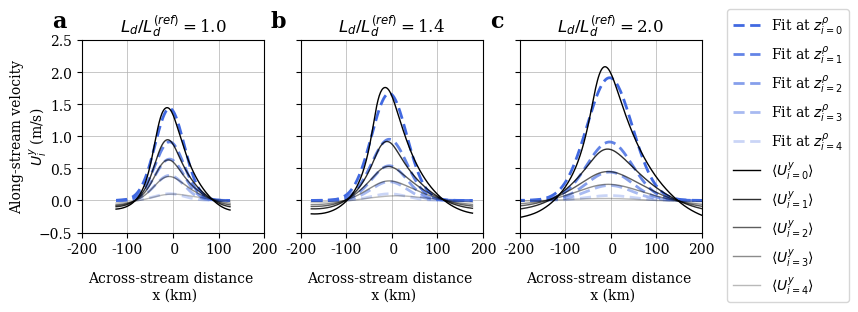

In [49]:
# Here we calculate the fits again and show the averaged vs. fitted profiles.

fig = plt.figure(figsize=(8, 2.5))
grid = plt.GridSpec(1, 3, hspace=0.3, wspace=0.2)
fitlabels = [r"Fit at $z^\rho_{i = 0}$", r"Fit at $z^\rho_{i = 1}$", r"Fit at $z^\rho_{i = 2}$", r"Fit at $z^\rho_{i = 3}$", r"Fit at $z^\rho_{i = 4}$"]
averagelabels = [r"$\langle U^y_{i = 0}\rangle$", r"$\langle U^y_{i = 1}\rangle$", r"$\langle U^y_{i = 2}\rangle$", r"$\langle U^y_{i = 3}\rangle$", r"$\langle U^y_{i = 4}\rangle$"]
plt.rcParams['font.family'] = 'serif'

drhos = [1,2,4]

# grid over which stability analysis was performed

# superparameters for stability analysis (checked for convergence)
dx_rescale = 4
domain_rescale = 0.5

# width and differentials for profile to be averaged for
profile_widths = 250e3*np.array([1, np.sqrt(2), 2])
dxs = 1e3*np.array([1, np.sqrt(2), 2])
N_prof_fit = int(profile_widths[0]/dxs[0])

Nl = 5 # number of layers

# store average directions
alpha_means = np.zeros(3)
dtopodx_means = np.zeros(3)
dtopody_means = np.zeros(3)
dfdy_means = np.zeros(3)
dfdx_means = np.zeros(3)
f0_means = np.zeros(3)
H_ms_means = np.zeros([3,Nl])
topo_means = np.zeros([3])
U_shear_means = np.zeros(3)
U_off_means = np.zeros(3)
decay_scale_horizontals = np.zeros(3)
decay_scale_verticals = np.zeros(3)

Ld_ratios = [1, np.sqrt(2), 2]
labels = ["a", "b", "c"]

for ind in range(3):

    print("starting drho_fac = " + str(drhos[ind]))
          
    dx = dxs[ind]
    profile_width = profile_widths[ind]
    
    # create along-across-stream coordinates
    dx = profile_width/(N_prof_fit - 1) # numerical delta in rotated beta-plane frame
    xs_fit = np.linspace(-profile_width/2, profile_width/2, N_prof_fit)
    
    i_core = int((N_prof_fit-1)/2)
    
    drho_fac = drhos[ind]
    # unpack pathwise mean variables
    
    path_avs_load = np.load("data/path_averages_" + str(drho_fac) + "drho.npz", allow_pickle = True)["arr_0"][None][0]['res']  # gulf_" + str(drho_fac) + "drho_lin_topo.npz", allow_pickle=True)["arr_0"][None][0]['res']
        
    N_t = len(path_avs_load)
    
    numerator_U = np.zeros(np.shape(path_avs_load[0][0]))
    numerator_isopycs = np.zeros(np.shape(path_avs_load[0][1]))
    numerator_topo = np.zeros(np.shape(path_avs_load[0][2]))
    numerator_dtopo_dx = np.zeros(np.shape(path_avs_load[0][3]))
    numerator_dtopo_dy = np.zeros(np.shape(path_avs_load[0][4]))
    numerator_f0 = np.zeros(np.shape(path_avs_load[0][5]))
    numerator_dfdx = np.zeros(np.shape(path_avs_load[0][6]))
    numerator_dfdy = np.zeros(np.shape(path_avs_load[0][7]))
    numerator_alphas = np.zeros(np.shape(path_avs_load[0][8]))
    denominator_y = np.zeros(np.shape(path_avs_load[0][9]))

    
    for i in range(N_t):
        # the variables stored here contain the y-integrals in equations 11 and 12 of the Supplementary Material. The time integral is performed via a summation, as the outputs were stored in regular intervals of 7 days.
        
        numerator_U += path_avs_load[i][0]
        numerator_isopycs += path_avs_load[i][1]
        numerator_topo += path_avs_load[i][2]
        numerator_dtopo_dx += path_avs_load[i][3]
        numerator_dtopo_dy += path_avs_load[i][4]
        numerator_f0 += path_avs_load[i][5]
        numerator_dfdx += path_avs_load[i][6]
        numerator_dfdy += path_avs_load[i][7]
        numerator_alphas += path_avs_load[i][8]
        denominator_y += path_avs_load[i][9]
        
    # Set up quasi-geostrophic stability model
    U_profile = numerator_U/denominator_y[:,None]
    isopycs_profile = np.sum(numerator_isopycs, axis = 0)/np.sum(denominator_y)
    topo_profile = np.sum(numerator_topo)/np.sum(denominator_y)
    dtopo_dx = np.sum(numerator_dtopo_dx)/np.sum(denominator_y)
    dtopo_dy = np.sum(numerator_dtopo_dy)/np.sum(denominator_y)
    f0 = np.sum(numerator_f0)/np.sum(denominator_y)
    df_dx = np.sum(numerator_dfdx)/np.sum(denominator_y)
    df_dy = np.sum(numerator_dfdy)/np.sum(denominator_y)
    alpha_mean = numerator_alphas/denominator_y[i_core]
    
    R = 6378e3 # radius of the earth
    
    # stratification
    g = 9.81
    rho0 = 1e3 # reference density
    drho = np.array([0.,1.01/rho0, 1.41/rho0,  1.72/rho0,  2.13/rho0])*drho_fac # difference between layers and top layer, top-to-bottom indexed
    g_primes = g*(drho[1:] - drho[:-1]) # reduced density
    
    # Layer Depths
    
    Nl = 5
    
    # # use still layer depths as base profile
    H_m = np.zeros(Nl)
    H_m[:-1] = isopycs_profile[:-1] - isopycs_profile[1:] # mean layer depths
    H_m[-1] = isopycs_profile[-1] - topo_profile
    topo_means[ind] =  topo_profile
    
    # Fit a function to the velocity base profile
    
    z = np.zeros(Nl)
    z[:-1] = (isopycs_profile[1:] + isopycs_profile[:-1])/2
    z[-1] = (isopycs_profile[-1] + topo_profile)/2
    
    X,Z = np.meshgrid(xs_fit,z)
    
    p0 = (1.5, 0, -1.5e4, 150e3, 400) # initial guess for parameters
    result, params, covariance = fit_2d_function(X,Z,U_profile.T,model,p0) #[int(i_core - N_fit/2):int(i_core + N_fit/2),:]
    
    # store parameters

    alpha_means[ind] = alpha_mean
    dtopodx_means[ind] = dtopo_dx
    dtopody_means[ind] = dtopo_dy
    dfdy_means[ind] = df_dy
    dfdx_means[ind] = df_dx
    f0_means[ind] = f0
    H_ms_means[ind,:] = H_m
    U_shear_means[ind] = params[0]
    U_off_means[ind] = params[1]
    decay_scale_horizontals[ind] = params[3]
    decay_scale_verticals[ind] = params[4]

    # plot fitted and original profiles

    N = 1/2
    
    ax = fig.add_subplot(grid[ind])

    model_fit = model(X,Z,params[0], params[1], params[2], params[3], params[4]).T
    model_full = model (X,Z,params[0], params[1], params[2], params[3], params[4]).T

    for plot_i in range(Nl):
        
        ax.plot(xs_fit, model_fit[:,plot_i], color = "royalblue", linewidth =2,dashes = [4,2], alpha = (5+ N - plot_i)/(5+ N), label = fitlabels[plot_i])
        
        ax.set_xlim([-200e3, 200e3])
        ax.set_ylim([-0.5,2.5])
        ax.grid(linewidth = 0.5)
        
    for plot_i in range(Nl):
        
        ax.plot(xs_fit, U_profile[:,plot_i], color = "black", linewidth = 1, alpha = (5+ N - plot_i)/(5+ N), label = averagelabels[plot_i])
        
    if ind == 0:
        ax.set_ylabel("Along-stream velocity\n" + r"$U^y_i$" +" (m/s)")
        ax.yaxis.set_label_coords(-0.18,0.5)
    else:
        ax.set_yticklabels([])

    ax.text(-0.125, 1.1, labels[ind], weight = "bold", horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, size = 16)
    
    ax.set_xlabel("Across-stream distance \n x (km)")
    ax.set_title(r'$L_d / L_d^{(ref)} = $' + f'{Ld_ratios[ind]:.1f}')
    ax.xaxis.set_label_coords(0.5,-0.2)
    ax.set_xticklabels(["-200", "-100", " 0", "100", "200"])

    if ind == 2:
        ax.legend(loc='center left', bbox_to_anchor=(1.1, 0.4))
    
plt.savefig('profiles.png', dpi = 200, bbox_inches='tight', format = 'png')

np.savez("path_averages.npz", {"topo_means":topo_means, 
                               "dtopodx_means":dtopodx_means, 
                               "dtopody_means":dtopody_means, 
                               "H_ms_means":H_ms_means,
                               "f0_means":f0_means, 
                               "dfdx_means":dfdx_means, 
                               "dfdy_means":dfdy_means, 
                               "U_shear_means":U_shear_means, 
                               "U_off_means":U_off_means, 
                               "decay_scale_horizontals":decay_scale_horizontals, 
                               "decay_scale_verticals":decay_scale_verticals,}, allow_pickle=True) 

In [53]:
H_ms_means

array([[ 276.38977745,  174.21650391,  191.08591732,  380.11575226,
        3760.36911475],
       [ 245.79296783,  174.55704963,  283.23693028,  294.25056788,
        3659.52618357],
       [ 242.70265334,  233.83994559,  265.30593954,  244.86025654,
        3979.0608992 ]])